In [1]:
import gc
import argparse
import yaml

import matplotlib.pyplot as plt
import numpy as np

from datatree import open_datatree
from scipy.stats import describe

from var_assim.plotting.presets import get_presets
from var_assim.plotting.bias_perc_error_over_time import make_grid_plot, test_make_grid_plot
from var_assim.plotting.filtering import filter_by_max_conceivable, filter_datatree_by_cost_ratio_memeff
from var_assim.plotting.pproc import get_angle_r2
from var_assim.config import PRIOR_PATH, NOISE_PATH, TRUTH_PATH, WINDOW_PATH, DATA_DIR_ABS
from var_assim.calibration.priors import ClimateModelPriors
from var_assim.calibration.noise import ClimateModelNoise
from var_assim.calibration.truth import ClimateModelTruth
from var_assim.calibration.windowing import AssimilationWindowing

presets, _ = get_presets()
plt.rcParams.update(presets)

# enable auto reload
%load_ext autoreload
%autoreload 2

In [2]:
# test_make_grid_plot()

In [3]:
presets, basefile = get_presets()
plt.rcParams.update(presets)
SAVE_FIGS = True

Models by grid:
- Row 1: AR(1), ssp2, 0.1 deg / dec
- Row 2: ar(1), ssp5, 0.1 deg / dec
- Row 3: AR(1), ssp2, 0.2 deg / dec
- Row 4: No noise, sps2, 0.1 deg / dec

In [4]:
# properties that change across models
panel_configs = {
    'pco2geowc_ssp245_ar1': {
        'prefix': 'var-assim-output',
        'ssp': 'ssp245',
        'model': 'pco2geowc_reg',
        'noise_model': 'AR1',
        'degpdec': 0.1
    },

    'pco2geowc_ssp585_ar1': {
        'prefix': 'var-assim-output',
        'ssp': 'ssp585',
        'model': 'pco2geowc_reg',
        'noise_model': 'AR1',
        'degpdec': 0.1
    },

    'pco2geowc_ssp245_ar1_repeat': {
        'prefix': 'var-assim-output',
        'ssp': 'ssp245',
        'model': 'pco2geowc_reg',
        'noise_model': 'AR1',
        'degpdec': 0.2
    },

    'pco2geowc_nn_ssp245': {
        'prefix': 'var-assim-output',
        'ssp': 'ssp245',
        'model': 'pco2geowc_nn',
        'noise_model': 'nn',
        'degpdec': 0.1
    },
}

# properties that are constant across models
angles_file = ['5', '11', '15', '21', '30', '35']
reg_noises = [True, True, True, False]
ECS = 3.0
NYRSRAMP = 50
windowing_config = 'four'
Nens = 1000
TMIN = 2025
ANGLE_MAX_CONCEIVABLE = 90.
ramp_rate = 'linear'

# get the assimilation windows for this config
with open(WINDOW_PATH) as f:
    window_config = yaml.safe_load(f)

windows = window_config[windowing_config]['windows']

In [5]:
# empty lists for filling later
angles = np.zeros((len(panel_configs), len(angles_file), len(windows), Nens))
angles_tr = np.zeros(len(angles_file))
angles_prior = np.zeros(Nens)

In [6]:
for idx, config in enumerate(panel_configs.keys()):
    # store config as local variables
    prefix = panel_configs[config]['prefix']
    ssp = panel_configs[config]['ssp']
    model = panel_configs[config]['model']
    noise_model = panel_configs[config]['noise_model']
    DEGpDEC = panel_configs[config]['degpdec']

    for angx, th in enumerate(angles_file):
        # make temporary CLI namespace for processing
        cli_args = argparse.Namespace(
            model=model,
            ssp=ssp,
            noise_model=noise_model,
            tmin=TMIN,
            theta=float(th),
            AR=1 if model != 'pco2geowc_nn' else None,
            ecs=ECS,
            DEGpDEC=DEGpDEC,
            NYRSRAMP=NYRSRAMP,
            Nens=Nens,
            reg_noise=reg_noises[idx],
            windowing=windowing_config
        )

        # setup data classes
        Noise = ClimateModelNoise.from_cli_and_yaml(cli_args, NOISE_PATH)
        Prior = ClimateModelPriors.from_cli_and_yaml_and_noise(cli_args, PRIOR_PATH, Noise)
        Windowing = AssimilationWindowing.from_cli_and_yaml(cli_args, WINDOW_PATH)
        Truth = ClimateModelTruth.from_cli_and_yaml(cli_args, TRUTH_PATH)

        # compute true value of angle
        if idx == 0:
            angles_tr[angx] = get_angle_r2(
                Truth.ALPHA_TR[0], Truth.ALPHA_TR[1],
                Truth.BETA_TR[0], Truth.BETA_TR[1],
                Truth.L_TR, Truth.EPS_TR, Truth.G_TR
                )
            if idx == 1:
                print(f"True values of the theta parameter are: {angles_tr}")

        # import data
        fname = DATA_DIR_ABS / "output" / model / (
                f"{prefix}_{ssp}_{model}_{windowing_config}_{noise_model}+reg_TMIN{TMIN}_THETA{th}_ECS{ECS}_ramprate{ramp_rate}_DEGpDEC{DEGpDEC}_NYRSRAMP{NYRSRAMP}_Nens{Nens}.nc"
                if reg_noises[idx]
                else f"{prefix}_{ssp}_{model}_{windowing_config}_{noise_model}_TMIN{TMIN}_THETA{th}_ECS{ECS}_ramprate{ramp_rate}_DEGpDEC{DEGpDEC}_NYRSRAMP{NYRSRAMP}_Nens{Nens}.nc"
            )

        ## variables we need for analysis (only do for first run through, constant across configs)
        if idx == 0 and angx == 0:
            dt_meta = open_datatree(fname, engine='netcdf4')
            relevant_vars = ['cost_hist', 'controls', 'controls_hist']
            dropped_vars = [v for v in dt_meta[str(windows[0])].ds.data_vars if v not in relevant_vars]
            # dt_meta.close()

        # open and clean dataset
        dt = open_datatree(fname, engine='netcdf4', drop_variables=dropped_vars)
        dt_clean = filter_datatree_by_cost_ratio_memeff(dt, threshold=5e1, clear_after_each_node=True)

        # make priors (only have to do once)
        if idx == 0 and angx == 0:
            prior_a1 = dt[str(windows[0])].ds.controls_hist.sel(vari='ALPHA_R1', iter=0).values
            prior_b1 = dt[str(windows[0])].ds.controls_hist.sel(vari='BETA_R1', iter=0).values
            prior_a2 = dt[str(windows[0])].ds.controls_hist.sel(vari='ALPHA_R2', iter=0).values
            prior_b2 = dt[str(windows[0])].ds.controls_hist.sel(vari='BETA_R2', iter=0).values
            prior_l = dt[str(windows[0])].ds.controls_hist.sel(vari='L', iter=0).values
            prior_g = dt[str(windows[0])].ds.controls_hist.sel(vari='G', iter=0).values
            prior_eps = dt[str(windows[0])].ds.controls_hist.sel(vari='EPS', iter=0).values

            for i in range(Nens):
                angles_prior[i] = get_angle_r2(prior_a1[i], prior_a2[i],
                                               prior_b1[i], prior_b2[i],
                                               prior_l[i], prior_eps[i], prior_g[i])
            
            print("Angle prior summary statistics:")
            for key, value in describe(angles_prior)._asdict().items():
                print(f"{key:>10}: {value}")

        # compute angles
        winds = np.array([w[1] for w in Windowing.windows])
        windss = [str(w) for w in winds]

        for w_, w in enumerate(windss):
            tmp_a1 = dt_clean[w].ds.controls.sel(vari='ALPHA_R1').values
            tmp_a2 = dt_clean[w].ds.controls.sel(vari='ALPHA_R2').values
            tmp_b1 = dt_clean[w].ds.controls.sel(vari='BETA_R1').values
            tmp_b2 = dt_clean[w].ds.controls.sel(vari='BETA_R2').values
            tmp_l = dt_clean[w].ds.controls.sel(vari='L').values
            tmp_g = dt_clean[w].ds.controls.sel(vari='G').values
            tmp_eps = dt_clean[w].ds.controls.sel(vari='EPS').values
            for i in range(Nens):
                angles[idx, angx, w_, i] = get_angle_r2(tmp_a1[i], tmp_a2[i],
                                                        tmp_b1[i], tmp_b2[i], 
                                                        tmp_l[i], tmp_eps[i], tmp_g[i])
                
        # cleanup
        for node in dt.subtree:
            if node.ds is not None:
                node.ds.close()

        del dt
        gc.collect()
                
angles_filtered = filter_by_max_conceivable(angles, ANGLE_MAX_CONCEIVABLE)


Found 5 nodes in tree
Processing node 1: /2040
  Memory: 25.1 MB
  Result: 999 kept, 1 filtered
Processing node 2: /2060
  Memory: 48.7 MB
  Result: 999 kept, 1 filtered
Processing node 3: /2080
  Memory: 72.3 MB
  Result: 999 kept, 1 filtered
Processing node 4: /2100
  Memory: 95.9 MB
  Result: 999 kept, 1 filtered

Rebuilding tree with 4 filtered nodes...
✓ Filtering complete
Angle prior summary statistics:
      nobs: 1000
    minmax: (0.06347207597053087, 98.09213780958842)
      mean: 15.917124253112872
  variance: 66.46778228526982
  skewness: 1.5155523199137748
  kurtosis: 10.277227619329459
Found 5 nodes in tree
Processing node 1: /2040
  Memory: 25.1 MB
  Result: 998 kept, 2 filtered
Processing node 2: /2060
  Memory: 48.7 MB
  Result: 998 kept, 2 filtered
Processing node 3: /2080
  Memory: 72.3 MB
  Result: 999 kept, 1 filtered
Processing node 4: /2100
  Memory: 95.9 MB
  Result: 999 kept, 1 filtered

Rebuilding tree with 4 filtered nodes...
✓ Filtering complete
Found 5 nodes

In [7]:
row_titles = [
    r'SSP2-4.5 | $\Delta$ T / decade = 0.1 $^\circ$C / decade | AR(1) Internal Variability | AR(0) Regional Noise',
    r'SSP5-8.5 | $\Delta$ T / decade = 0.1 $^\circ$C / decade | AR(1) Internal Variability | AR(0) Regional Noise',
    r'SSP2-4.5 | $\Delta$ T / decade = 0.2 $^\circ$C / decade | AR(1) Internal Variability | AR(0) Regional Noise',
    r'SSP2-4.5 | $\Delta$ T / decade = 0.1 $^\circ$C / decade | No Internal Variability | No Regional Noise',
]

Figure saved to: /project/bbcael/ambauer/learning_sai/analysis/figs/results/2026-09-21-grid-bias-error-reg-four-TMIN2025-Nens1000-5-95range.png


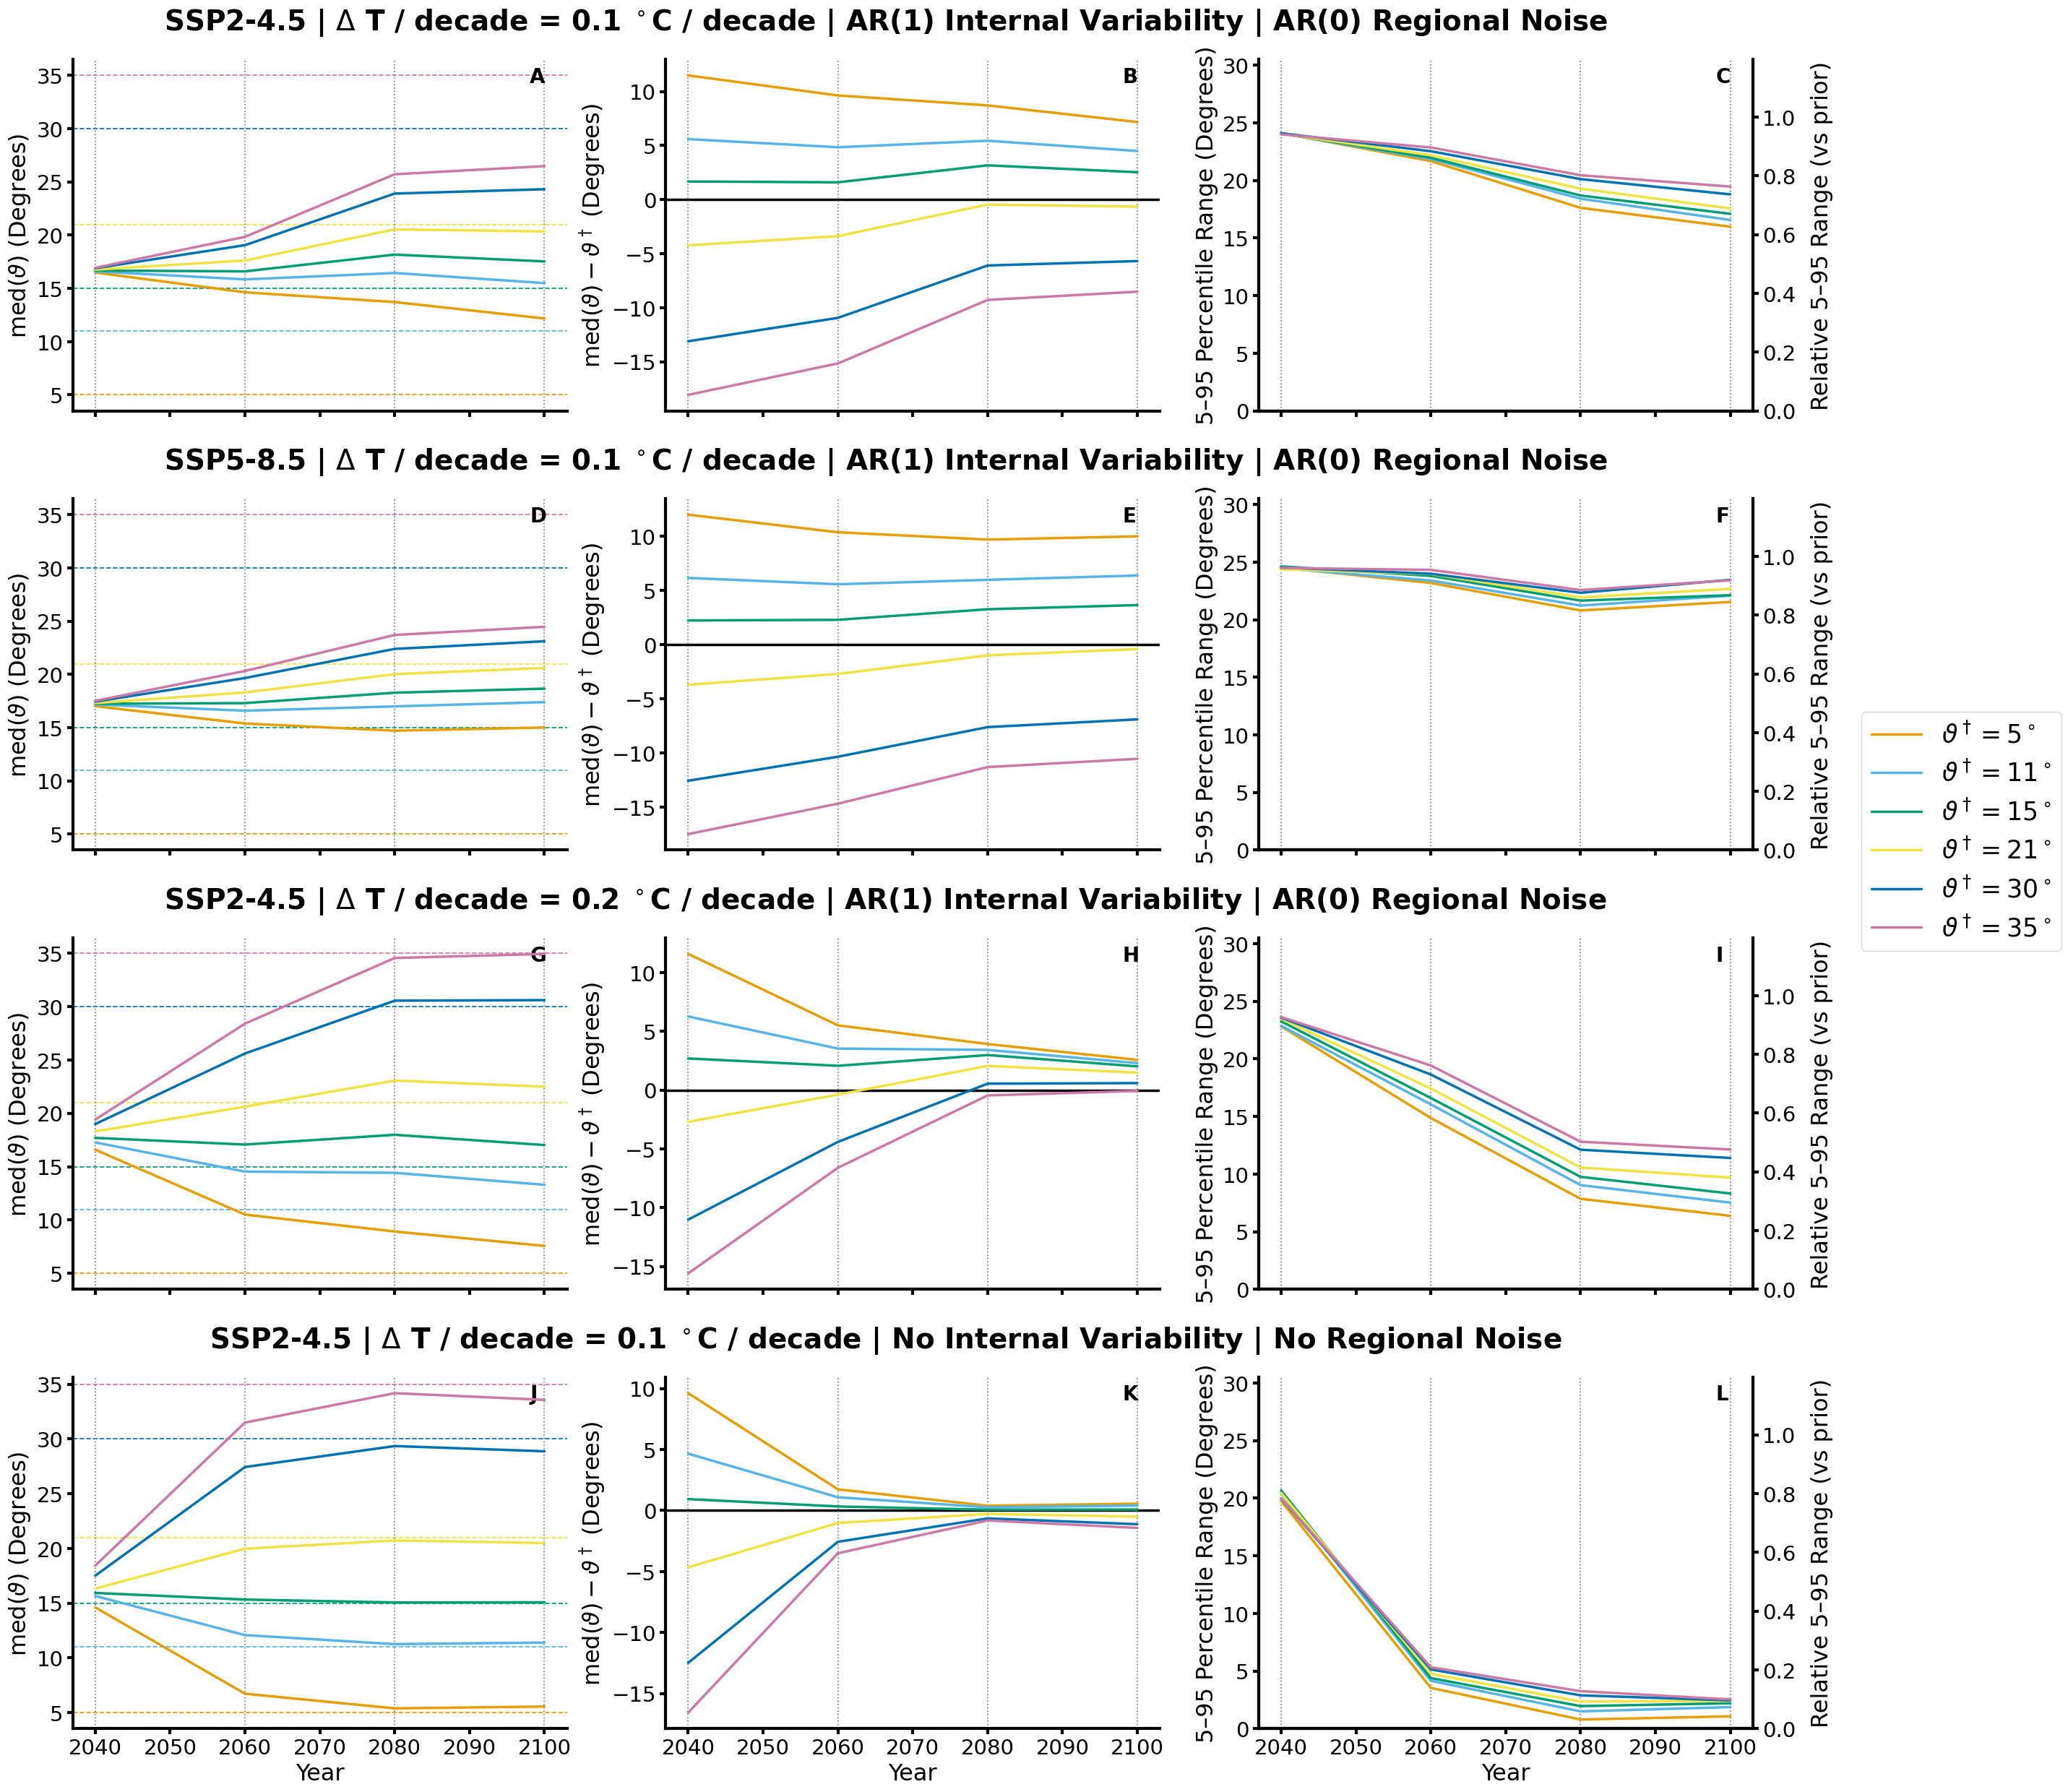

In [8]:
PLO = 5
PHIGH = 95

_, _ = make_grid_plot(angles, angles_tr, angles_prior, angles_file,
                     winds, PLO=PLO, PHI=PHIGH,
                     row_titles=row_titles,
                     save_figs=SAVE_FIGS,
                     fname=f'grid-bias-error-reg-{windowing_config}-TMIN{TMIN}-Nens{Nens}-{PLO}-{PHIGH}range',
                     YLIM_OFFSET=5)

plt.show()

In [4]:
# diagnostics
prefix = 'var-assim-output'
ssp = 'ssp245'
model = 'pco2geowc_reg'
windowing_config = 'ws_gradual'
noise_model = 'AR1'
TMIN = 2023
th = 15
ECS = 3.0
DEGpDEC = 0.1
NYRSRAMP = 50
Nens = 1000


fname = DATA_DIR_ABS / 'output' / model / f"{prefix}_{ssp}_{model}_{windowing_config}_{noise_model}+reg_TMIN{TMIN}_THETA{th}_ECS{ECS}_DEGpDEC{DEGpDEC}_NYRSRAMP{NYRSRAMP}_Nens{Nens}.nc"

In [5]:
dt = open_datatree(fname)

In [6]:
wind = 2100
ds = dt[str(wind)].ds
ds

<xarray.DatasetView>
Dimensions:         (ens_mem: 1000, vari: 249, time: 78, iter: 101, obs_var: 4)
Coordinates:
  * time            (time) int64 2023 2024 2025 2026 ... 2097 2098 2099 2100
  * iter            (iter) int64 0 1 2 3 4 5 6 7 8 ... 93 94 95 96 97 98 99 100
  * vari            (vari) object 'T1' 'T2' 'Q' ... 'qR2_75' 'qR2_76' 'qR2_77'
  * ens_mem         (ens_mem) int64 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
  * obs_var         (obs_var) object 'T1' 'Q' 'T_R1' 'T_R2'
Data variables:
    data_final      (ens_mem, vari, time) float64 ...
    l2s             (ens_mem) float64 ...
    costs           (ens_mem) float64 ...
    controls        (ens_mem, vari) float64 ...
    data_hist       (ens_mem, vari, iter, time) float64 ...
    l2_hist         (ens_mem, iter) float64 ...
    cost_hist       (ens_mem, iter) float64 ...
    controls_hist   (ens_mem, vari, iter) float64 ...
    flag            (ens_mem) int64 ...
    obs             (obs_var, time) float64 ...
    data_truth      (vari, time) float64 ...
    controls_truth  (vari) float64 ...
Attributes: (12/18)
    reg_noise:         True
    model:             pco2geowc_reg
    tol:               0.01
    debug:             False
    n_yrs_ramp:        50
    tmin:              2023
    ...                ...
    run_time:          2172.0938923358917
    command:           /project/bbcael/ambauer/envs/var_assim_sai/bin/var-ass...
    noise_model:       AR1
    max_iter:          100
    windowing:         ws_gradual
    scenario:          ssp245

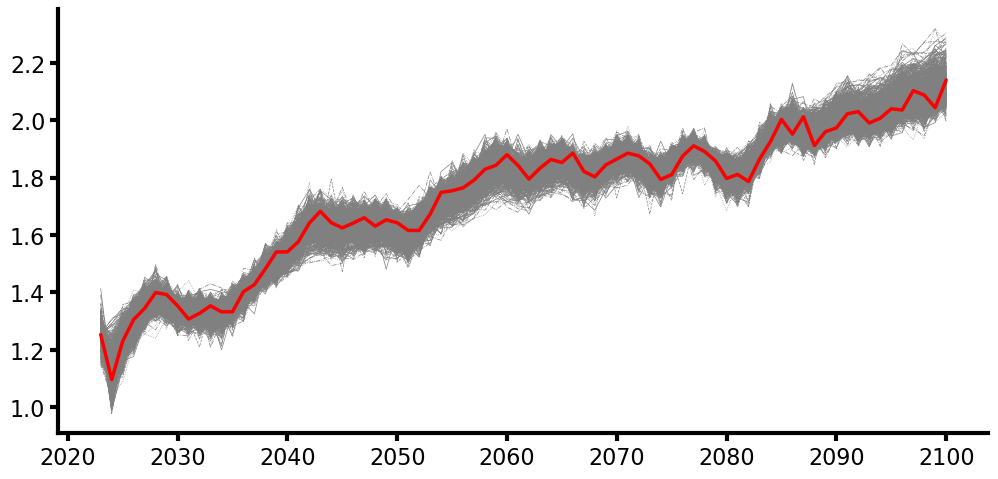

In [12]:
r=2
plt.plot(ds.time, ds.data_truth.sel(vari=f'T_R{r}'), color='r', zorder=1000)

for mem in range(ds.ens_mem.size):
    plt.plot(ds.time, ds.data_final.sel(vari=f'T_R{r}', ens_mem=mem), color='grey', lw=0.5)

# plt.ylim((-10, 10))